# MIW CWFS Intrinsic Check (v1)

**Author:** Aaron Roodman
**Date Created:** 2026-07-13
**Last Modified:** 2026-07-13
**Status:** In Progress
**Keywords:** MIW, intrinsic wavefront, CWFS, IntrinsicZernikes, OCS, CCS, AOS validation

## Description

The Measured Intrinsic Wavefront (MIW) went live in the AOS.  This notebook
verifies that the **correct intrinsic values were used** for the 4 corner
wavefront sensors (CWFS) on regular (science) images, by independently
recomputing the expected intrinsic from **my own calibration source tables** and
comparing to the `zk_intrinsic_*` stored in the live aggregate tables.

The live path (traced in `ts_intrinsic_wavefront`): the AOS applies
`lsst.ip.isr.IntrinsicZernikes(table=<per-detector CCS>, table_ocs=<OCS>)` and
stores, per donut,
`calib.getIntrinsicZernikes(field_x, field_y, rotTelPos=...)`.
So the check rebuilds that exact calib object from the OCS + per-detector CCS
source parquets, evaluates it at each CWFS donut's field position and the
visit rotator, and differences against the aggregate.

Because a handful of frame conventions (field-argument order, rotator
sign/offset, and which of the aggregate's OCS/CCS/NW intrinsic columns
`getIntrinsicZernikes` reproduces) are not obvious a priori, the notebook
**auto-solves** that small discrete space against the aggregate: the config that
reproduces the stored intrinsic (correlation ~1, slope ~1, tiny residual)
confirms the correct values were used *and* tells us the convention; if **no**
config matches, that is the alarm (wrong / stale calib ingested, or a bug).

A separate validation section plots the OCS and CCS focal-plane maps (as in
`aos_miw_ocs_ccs_maps.ipynb`) as a further sanity check on the maps behind the
calib.

**Output:** `output/miw_cwfs_intrinsic_check.parquet` (per donut x Noll:
expected vs aggregate + residual) and the comparison / map figures.

**References:** `ts_intrinsic_wavefront` `calib_tables.py`,
`bin.src/run_make_calib_tables.py`, `bin.src/ingest_calib_tables.py`
(`IntrinsicZernikes(table=ccs, table_ocs=ocs)` /
`getIntrinsicZernikes(field_x, field_y, rotTelPos)`); `aos_miw_ocs_ccs_maps.ipynb`.

## Change Log

| Date | Author | Description |
|------|--------|-------------|
| 2026-07-13 | Aaron Roodman | Initial version — CWFS intrinsic verification vs live aggregate + OCS/CCS map validation |
| 2026-07-21 | Aaron Roodman | Add `WHICH` collection selector (`refitwcs_t668` default / `nightly68`); the refitWcs run applies the donut_viz 1.725 deg `maxFieldDist` cut so donuts stay inside the 1.75 deg MIW hull. Query on `visit.day_obs`. |

## Table of Contents

1. [Parameters](#params)
2. [Setup & Imports](#setup)
3. [Load calib source tables -> IntrinsicZernikes](#calib)
4. [Validation: OCS / CCS focal-plane maps](#maps)
5. [Load aggregate CWFS donuts (last night)](#agg)
6. [Recompute expected intrinsic + auto-solve convention](#recompute)
7. [Comparison plots + PASS/FAIL](#compare)
8. [NaN diagnosis -- OCS hull vs CCS footprint](#nandiag)
9. [NaN vs field radius, and which term causes it](#radius)

<a id='params'></a>
## 1. Parameters

In [ ]:
# ============================================================
# Parameters
# ============================================================
from datetime import date, timedelta

# ---- choose which processed collection to validate the MIW against ----
# "refitwcs_t668": the paired refitWcs CWFS run.  donut_viz applies
#     generateDonutFromRefitWcsTask.donutSelector.maxFieldDist = 1.725 deg, so every
#     accepted donut sits INSIDE the 1.75 deg MIW interpolation hull -> expect ~0% NaN.
#     This is the clean MIW test.  (visit-keyed, one aggregate per visit.)
# "nightly68": the nightlyValidation run for the same night.  It did NOT apply the
#     1.725 deg cut, so donuts run out to ~1.84 deg -> ~37% NaN at the FoV edge; and
#     the live MIW was NOT applied there, so the PASS/FAIL vs zk_intrinsic is not
#     meaningful -- only the finite/NaN sanity result is.
WHICH = "refitwcs_t668"
COLLECTION_SETS = {
    "refitwcs_t668": dict(
        collections=["LSSTCam/runs/aos/cwfs/danish_1_2_0/wep_17_7_0/dv_4_7_0/"
                     "bin_x2/paired/block-T668/refitWcs"],
        day_obs=20260713),
    "nightly68": dict(
        collections=["LSSTCam/runs/nightlyValidation/68"],
        day_obs=20260713),
}

# ---- Butler + the per-donut-pair Raw aggregate for the night's regular images ----
# quickLook is Summit-only; at USDF read the collection above for the night.
# (USE_SUMMIT_BUTLER=True uses the Summit embargo quickLook chain instead -- but that
#  has only the Avg.)  Both collections here are keyed on `visit` (visit.day_obs).
USE_SUMMIT_BUTLER = False                        # False -> Butler(BUTLER_REPO, collections=COLLECTIONS)
BUTLER_REPO  = "/repo/embargo"                   # 20260713 AOS output lives here (not /repo/main)
COLLECTIONS  = COLLECTION_SETS[WHICH]["collections"]
DATASET_TYPE = "aggregateAOSVisitTableRaw"       # both runs have Raw + Avg + zernikes
DAY_OBS      = COLLECTION_SETS[WHICH]["day_obs"]
MAX_SEQ      = None      # None = all visits; or an int to load only the first N visits (fast peek)
print(f"WHICH={WHICH}  ->  {COLLECTIONS[0]}  (day_obs={DAY_OBS})")

# ---- My own calib SOURCE tables (mirrors the USDF rubin-data layout) ----
CALIB_DIR = "~/notebooks/rubin-data/aos/intrinsic_zernikes/v2_ajr"   # OCS + per-detector CCS
OCS_FILE  = "intrinsic_aberrations_OCS.parquet" # per-instrument OCS table (whole map)
# per-detector CCS tables expected as  intrinsic_aberrations_CCS_det<NNN>.parquet

# ---- MIW maps for the OCS/CCS validation plots (set None to skip that section) ----
MAPS_PATH = "~/notebooks/rubin-data/aos/intrinsic_zernikes/intrinsic_split_maps.parquet"

# ---- CWFS detectors: the Avg table carries the 4 SW0 corners (as in olr) ----
CWFS = {191: "R00_SW0", 195: "R04_SW0", 199: "R40_SW0", 203: "R44_SW0"}

# ---- frame conventions: SET these, don't auto-solve (a mismatch shows in the plots) ----
FIELD_ORDER   = ("thx_CCS", "thy_CCS")           # (field_x, field_y) base cols for getIntrinsicZernikes
RTP_SIGN      = +1                                # meta rotTelPos (converted to deg) is multiplied by this
COMPARE_FRAME = "OCS"                             # aggregate zk_intrinsic frame to compare: OCS | CCS | NW
TOL_UM        = 0.01                             # PASS if max median|expected-aggregate| <= this (µm)
OUT_PARQUET   = "output/miw_cwfs_intrinsic_check.parquet"
FP_RADIUS_DEG = 1.75
PCT           = 98                               # map color percentile

<a id='setup'></a>
## 2. Setup & Imports

In [ ]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.table import Table
from tqdm import tqdm                              # plain text bar (no ipywidgets)

from lsst.daf.butler import Butler
from lsst.ip.isr import IntrinsicZernikes

if USE_SUMMIT_BUTLER:                            # same as olr/nightly_table.py
    from lsst.summit.utils import butlerUtils
    butler = butlerUtils.makeDefaultButler("LSSTCam", embargo=True)
else:
    butler = Butler(BUTLER_REPO, collections=COLLECTIONS)
NAME2ID = {v: k for k, v in CWFS.items()}


def to_deg(a):
    """Angles to degrees (aggregate positions may be stored in radians)."""
    a = np.asarray(a, float)
    return np.degrees(a) if np.nanmax(np.abs(a)) < 0.2 else a

<a id='calib'></a>
## 3. Load calib source tables -> IntrinsicZernikes

Reconstructs the exact `IntrinsicZernikes(table=ccs, table_ocs=ocs)` the AOS ingested, one per CWFS detector, from **my own** source parquets.

In [ ]:
# Rebuild the exact calib the AOS ingested: shared OCS + per-detector CCS.
# ts_wep evaluates the intrinsic per donut with THAT donut's own CCD calib, so we
# need both the extra (SW0, the row detector) AND the intra (SW1 = SW0+1) halves.
cdir = Path(CALIB_DIR).expanduser()
ocs = Table.read(str(cdir / OCS_FILE), format="parquet")
det_ids = sorted(set(CWFS) | {d + 1 for d in CWFS})   # SW0 (extra) + SW1 (intra)
calib_by_det, missing = {}, []
for det in det_ids:
    p = cdir / f"intrinsic_aberrations_CCS_det{det:03d}.parquet"
    if p.exists():
        calib_by_det[det] = IntrinsicZernikes(table=Table.read(str(p), format="parquet"),
                                              table_ocs=ocs)
    else:
        missing.append(det)
if missing:
    print(f"WARNING: missing CCS tables for detectors {missing} "
          f"(need the full v2_ajr set incl. SW1: 192/196/200/204)")
assert calib_by_det, "no calibs loaded -- check CALIB_DIR / OCS_FILE / CCS filenames"

calib_noll = [int(x) for x in np.asarray(next(iter(calib_by_det.values())).noll_indices)]
print(f"loaded {len(calib_by_det)} calibs (SW0 extra + SW1 intra): {sorted(calib_by_det)}")
print(f"calib Noll (n={len(calib_noll)}): {calib_noll}")

<a id='maps'></a>
## 4. Validation: OCS / CCS focal-plane maps

Reuses `optatmo/code/plot_miw_maps.py` on the calib's own interpolators: Z4 OCS (`interpolator_ocs` on a global grid) vs Z4 CCS (rendered **per-CCD** from each detector's interpolator, so the per-CCD height steps show at full resolution), then OCS maps Z5-Z11. DVCS orientation (x_field vertical, y_field horizontal).

In [ ]:
# Reuse optatmo/code/plot_miw_maps.py: render from the calib's OWN interpolators.
#   Z4 OCS  -> calib.interpolator_ocs on a global grid (imshow)
#   Z4 CCS  -> one patch per CCD via that detector's interpolator (per-CCD height
#              steps preserved, no cross-CCD blending)
#   Z5..Z11 OCS.  DVCS orientation: x_field vertical, y_field horizontal.
import glob
from matplotlib.patches import Circle

LIM, OCS_N, CCS_SUB = FP_RADIUS_DEG, 71, 10

# a calib per available detector -> full-focal-plane CCS map (all CCDs if built)
calibs_all = {}
for f in sorted(glob.glob(str(cdir / "intrinsic_aberrations_CCS_det*.parquet"))):
    det = int(re.search(r"det(\d+)\.parquet", f).group(1))
    calibs_all[det] = IntrinsicZernikes(table=Table.read(f, format="parquet"), table_ocs=ocs)
cal0 = next(iter(calibs_all.values()))
noll_c = [int(j) for j in np.asarray(cal0.noll_indices)]
kc = {j: i for i, j in enumerate(noll_c)}
print(f"maps: {len(calibs_all)} detector calibs; Noll {noll_c}")


def _vlim(v, pct=99.0):
    v = np.asarray(v, float); v = v[np.isfinite(v)]
    return max(float(np.percentile(np.abs(v), pct)), 1e-6) if v.size else 1.0


def _dvcs(ax, title):
    ax.add_patch(Circle((0, 0), FP_RADIUS_DEG, fill=False, ls="--", color="k", lw=0.5, alpha=0.5))
    ax.set_aspect("equal"); ax.set_xlim(-LIM, LIM); ax.set_ylim(-LIM, LIM)
    ax.set_title(title, fontsize=9); ax.tick_params(labelsize=6)
    ax.set_xlabel("y_field [deg]", fontsize=7); ax.set_ylabel("x_field [deg]", fontsize=7)


def _imshow(ax, Z, title, sample_xy=None):
    vl = _vlim(Z)
    im = ax.imshow(Z.T, origin="lower", extent=[-LIM, LIM, -LIM, LIM], cmap="RdBu_r",
                   vmin=-vl, vmax=vl, interpolation="nearest")
    if sample_xy is not None:
        ax.plot(sample_xy[1], sample_xy[0], ".", ms=0.5, color="k", alpha=0.15)
    _dvcs(ax, title); return im


_ax = np.linspace(-LIM, LIM, OCS_N)
gx, gy = np.meshgrid(_ax, _ax)
gg = np.column_stack([gx.ravel(), gy.ravel()])
ocs_xy = (np.asarray(cal0.field_x_ocs), np.asarray(cal0.field_y_ocs))
def ocs_map(j):
    return np.asarray(cal0.interpolator_ocs(gg))[:, kc[j]].reshape(gx.shape)

# per-CCD Z4 CCS patches (skip whole-FP height-only field-edge CCDs)
patches, n_skip = [], 0
for d, c in calibs_all.items():
    fx, fy = np.asarray(c.field_x), np.asarray(c.field_y)
    if fx.size >= 0.5 * ocs_xy[0].size:
        n_skip += 1; continue
    ex = np.linspace(fx.min(), fx.max(), CCS_SUB + 1)
    ey = np.linspace(fy.min(), fy.max(), CCS_SUB + 1)
    ggx, ggy = np.meshgrid(0.5 * (ex[:-1] + ex[1:]), 0.5 * (ey[:-1] + ey[1:]))
    z = np.asarray(c.interpolator(np.column_stack([ggx.ravel(), ggy.ravel()])))
    patches.append((ex, ey, z[:, kc[4]].reshape(ggx.shape)))
vl_ccs = _vlim(np.concatenate([p[2].ravel() for p in patches])) if patches else 1.0

fig, ax = plt.subplots(1, 2, figsize=(13, 6))
i0 = _imshow(ax[0], ocs_map(4), "Z4 OCS [µm] (calib.interpolator_ocs)", sample_xy=ocs_xy)
fig.colorbar(i0, ax=ax[0], shrink=0.8)
im = None
for ex, ey, z in patches:                     # DVCS: horizontal=field_y, vertical=field_x
    im = ax[1].pcolormesh(ey, ex, np.ma.masked_invalid(z.T), cmap="RdBu_r",
                          vmin=-vl_ccs, vmax=vl_ccs, shading="flat")
_dvcs(ax[1], f"Z4 CCS [µm] (per-CCD {CCS_SUB}x{CCS_SUB}, incl. height)")
if im is not None:
    fig.colorbar(im, ax=ax[1], shrink=0.8)
fig.suptitle("MIW calib (v2_ajr) — Z4 (defocus): OCS vs CCS  (DVCS)")
fig.tight_layout(); plt.show()
print(f"CCS: {len(patches)} footprint CCDs rendered, {n_skip} height-only skipped")

js = [j for j in range(5, 12) if j in kc]     # OCS maps Z5..Z11
if js:
    cols = 4; rows = int(np.ceil(len(js) / cols))
    fig, axs = plt.subplots(rows, cols, figsize=(4.0 * cols, 3.7 * rows))
    axs = np.atleast_1d(axs).ravel()
    for a, j in zip(axs, js):
        fig.colorbar(_imshow(a, ocs_map(j), f"Z{j} OCS [µm]", sample_xy=ocs_xy), ax=a, shrink=0.8)
    for a in axs[len(js):]:
        a.axis("off")
    fig.suptitle("MIW calib (v2_ajr) — OCS maps Z5-Z11  (DVCS)")
    fig.tight_layout(); plt.show()

<a id='agg'></a>
## 5. Load aggregate CWFS donuts (last night)

The live **Raw** aggregate for regular images (one row per donut pair, so we see the intrinsic used per donut), from the collection chosen in `WHICH` (Parameters), keyed by `visit.day_obs`. The default `refitwcs_t668` run applies the donut_viz `maxFieldDist = 1.725 deg` cut, so all donuts sit inside the 1.75 deg MIW hull (expect ~0% NaN); `nightly68` does not. Keep the CWFS rows with their field positions and the stored `zk_intrinsic_*`.

In [ ]:
# Pull last night's per-donut-pair aggregates (Raw) and keep the CWFS rows.
# Both refitWcs and nightlyValidation are visit-keyed -> filter on visit.day_obs.
# NOTE: the ~minutes here is Butler datastore I/O (reading each parquet from the
# /repo/embargo store), not notebook-side work.  See the separate benchmark snippet
# to decide whether threaded reads help on this RSP before adding that complexity.
refs = list(butler.query_datasets(DATASET_TYPE,
            where=f"instrument='LSSTCam' AND visit.day_obs = {DAY_OBS}", explain=False))
refs.sort(key=lambda r: int(r.dataId["visit"]))     # by seq_num order
if MAX_SEQ:                                          # fast peek: first N seq_num only
    refs = refs[:int(MAX_SEQ)]
    print(f"MAX_SEQ={MAX_SEQ}: limiting to the first {len(refs)} visits")
print(f"loading {len(refs)} {DATASET_TYPE} datasets on day_obs={DAY_OBS}")

FRAME_COLS = ("OCS", "CCS")                       # NW intrinsic frame is never used
rows, agg_noll, shown = [], None, False
for ref in tqdm(refs, desc="Butler aggregate"):
    t = butler.get(ref)
    if not shown:                                # report the schema of the live table once
        print("aggregate columns:", list(t.colnames))
        print("meta keys:", list(t.meta))
        print("detectors present:", sorted(set(str(x) for x in t["detector"])))
        shown = True
    if agg_noll is None and t.meta.get("nollIndices") is not None:
        agg_noll = [int(x) for x in t.meta["nollIndices"]]
    ids = np.array([NAME2ID.get(d, int(d) if d.lstrip("-").isdigit() else -1)
                    for d in np.asarray(t["detector"]).astype(str)])
    keep = np.isin(ids, list(CWFS))                 # rows are the SW0 (extra) corners
    if not keep.any():
        continue
    sub = t[keep]
    # ts_wep evaluates the intrinsic at each stamp's own CCS position; the aggregate
    # carries thx_CCS_intra/extra + thy_CCS_intra/extra, and rtp in meta['rotTelPos'].
    zkI = {f: np.asarray(sub[f"zk_intrinsic_{f}"], float)
           for f in FRAME_COLS if f"zk_intrinsic_{f}" in t.colnames}
    # meta['rotTelPos'] is in RADIANS -> degrees, wrapped to (-180, 180] (physical ~+-90)
    rtp_deg = (float(np.degrees(t.meta["rotTelPos"])) + 180.0) % 360.0 - 180.0
    rows.append(dict(
        visit=int(ref.dataId["visit"]),
        seq=int(ref.dataId["visit"] - DAY_OBS * 100000),
        det_id=ids[keep],
        rtp=rtp_deg,
        # per-stamp CCS positions (what ts_wep passes to getIntrinsicZernikes)
        thx_CCS_intra=to_deg(sub["thx_CCS_intra"]), thy_CCS_intra=to_deg(sub["thy_CCS_intra"]),
        thx_CCS_extra=to_deg(sub["thx_CCS_extra"]), thy_CCS_extra=to_deg(sub["thy_CCS_extra"]),
        # per-stamp OCS positions (for the radius / term diagnosis in section 9)
        thx_OCS_intra=to_deg(sub["thx_OCS_intra"]), thy_OCS_intra=to_deg(sub["thy_OCS_intra"]),
        thx_OCS_extra=to_deg(sub["thx_OCS_extra"]), thy_OCS_extra=to_deg(sub["thy_OCS_extra"]),
        thx_CCS=to_deg(sub["thx_CCS"]), thy_CCS=to_deg(sub["thy_CCS"]),   # pair mean, for plots
        zkI=zkI))

assert rows, "no CWFS rows found -- check DATASET_TYPE / DAY_OBS / detector names"
frames = [f for f in FRAME_COLS if all(f in r["zkI"] for r in rows)]
print(f"{len(rows)} visits with CWFS rows; aggregate Noll (n={len(agg_noll)}): {agg_noll}")
print(f"intrinsic frames present: {frames}; rtp range "
      f"{min(r['rtp'] for r in rows):.1f}..{max(r['rtp'] for r in rows):.1f} deg")

# rotTelPos per seq_num (meta['rotTelPos']) -- check against expectations
print("\nrotTelPos per seq_num:")
for r in sorted(rows, key=lambda x: x["seq"]):
    print(f"  seq {r['seq']:>5d}  (visit {r['visit']})  rotTelPos = {r['rtp']:+8.3f} deg")

<a id='recompute'></a>
## 6. Recompute expected intrinsic (ts_wep recipe)

Reproduces `ts_wep` `calcZernikesTask`: for each pair, evaluate `getIntrinsicZernikes(field_x, field_y, rotTelPos)` at the **extra** stamp position (SW0 calib) and the **intra** stamp position (SW1 calib), then **average** the two — `rtp` from `meta['rotTelPos']` (radians -> degrees). The field-arg order, rtp sign, and comparison frame are taken from the Parameters (`FIELD_ORDER`, `RTP_SIGN`, `COMPARE_FRAME`) — not auto-solved. A per-frame `mean|corr|` is printed as a hint, but a mismatch will simply show in the plots.

In [ ]:
# Common Noll between calib and aggregate.
common = [j for j in agg_noll if j in calib_noll]
ai = [agg_noll.index(j) for j in common]        # -> aggregate zk_intrinsic columns
print(f"comparing {len(common)} shared Noll: {common}")


def eval_visit(r, fxb, fyb, rot):
    """ts_wep recipe: intrinsic at the EXTRA stamp position (SW0 calib) and the
    INTRA stamp position (SW1=SW0+1 calib), then averaged.  (n, len(common))."""
    n = len(r["det_id"])
    Ie = np.full((n, len(common)), np.nan)
    Ii = np.full((n, len(common)), np.nan)
    for de in np.unique(r["det_id"]):
        m = r["det_id"] == de
        di = int(de) + 1                            # SW1 (intra) partner
        Ie[m] = np.atleast_2d(calib_by_det[int(de)].getIntrinsicZernikes(
            field_x=np.asarray(r[fxb + "_extra"][m], float),
            field_y=np.asarray(r[fyb + "_extra"][m], float),
            rotTelPos=float(rot), noll_indices=common))
        if di in calib_by_det:
            Ii[m] = np.atleast_2d(calib_by_det[di].getIntrinsicZernikes(
                field_x=np.asarray(r[fxb + "_intra"][m], float),
                field_y=np.asarray(r[fyb + "_intra"][m], float),
                rotTelPos=float(rot), noll_indices=common))
        else:
            Ii[m] = Ie[m]                           # SW1 calib absent -> extra-only
    return 0.5 * (Ie + Ii)


# ---- fixed conventions from Parameters (no auto-solve) ----
FXB, FYB = FIELD_ORDER
FRAME = COMPARE_FRAME
print(f"conventions: field=({FXB},{FYB}), rtp sign={RTP_SIGN:+d}, compare-frame={FRAME}")

# hint only: mean|corr| of the expected vs EACH aggregate frame on a sample, so a
# wrong COMPARE_FRAME is obvious without changing what is used.
_smp = rows[:min(6, len(rows))]
_E = np.vstack([eval_visit(r, FXB, FYB, RTP_SIGN * r["rtp"]) for r in _smp])
for f in frames:
    _A = np.vstack([r["zkI"][f][:, ai] for r in _smp])
    cs = []
    for p in range(len(common)):
        x, y = _E[:, p], _A[:, p]
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() > 3 and np.std(x[m]) > 0 and np.std(y[m]) > 0:
            cs.append(abs(np.corrcoef(x[m], y[m])[0, 1]))
    print(f"  vs {f}: mean|corr| = {np.mean(cs) if cs else float('nan'):.3f}"
          + ("   <- COMPARE_FRAME" if f == FRAME else ""))

# ---- apply to ALL visits -> tidy comparison ----
recs = []
for r in rows:
    E = eval_visit(r, FXB, FYB, RTP_SIGN * r["rtp"])
    A = r["zkI"][FRAME][:, ai]
    for k, det in enumerate(r["det_id"]):
        for p, j in enumerate(common):
            recs.append(dict(visit=r["visit"], corner=CWFS[int(det)], j=int(j),
                             expected=E[k, p], aggregate=A[k, p], rtp=r["rtp"]))
cmp = pd.DataFrame(recs)
cmp["resid"] = cmp["expected"] - cmp["aggregate"]   # bracket: .aggregate is a DataFrame method
Path(OUT_PARQUET).parent.mkdir(parents=True, exist_ok=True)
cmp.to_parquet(OUT_PARQUET)

fin = np.isfinite(cmp["expected"]) & np.isfinite(cmp["aggregate"])
sl, off = np.polyfit(cmp["aggregate"][fin], cmp["expected"][fin], 1)
print(f"expected = {sl:.4f} * aggregate {off:+.4f}   (slope~1, offset~0 => values match; "
      f"slope~1e6/1e-6 => a unit mismatch)")
print(f"wrote {OUT_PARQUET}  ({len(cmp)} rows)")

# ---- MIW calib sanity: are the recomputed intrinsics FINITE and reasonable? ----
# (This is the useful check on data where the MIW was NOT applied, e.g.
#  nightlyValidation -- the PASS/FAIL vs the aggregate is only meaningful when
#  THIS MIW was the one applied.)
exp = cmp["expected"].to_numpy(float)
nan_frac = float(np.mean(~np.isfinite(exp)))
fin = exp[np.isfinite(exp)]
print(f"\nMIW calib sanity: {len(exp)} expected values, {100 * nan_frac:.1f}% NaN")
if fin.size:
    print(f"  |expected| median {np.median(np.abs(fin)):.3f}, "
          f"95pct {np.percentile(np.abs(fin), 95):.3f}, max {np.max(np.abs(fin)):.3f} µm "
          f"(intrinsic Zernikes should be ~sub-µm to a few µm)")
nan_by_corner = (cmp.assign(bad=~np.isfinite(cmp["expected"]))
                    .groupby("corner")["bad"].mean())
print("  NaN fraction by corner:", {c: round(float(v), 3) for c, v in nan_by_corner.items()})
if nan_frac > 0:
    nan_by_j = (cmp.assign(bad=~np.isfinite(cmp["expected"]))
                   .groupby("j")["bad"].mean())
    bad_j = [int(j) for j, v in nan_by_j.items() if v > 0]
    print(f"  WARNING: MIW returned NaN at some CWFS positions (Noll {bad_j}). Likely the "
          f"(rotated) field point fell outside the calib interpolation hull -- corners near "
          f"the 1.75 deg edge, or a missing Noll in the OCS/CCS tables.")
else:
    print("  OK: MIW returned finite values at every CWFS position.")

print("\nNOTE: on nightlyValidation the MIW was NOT applied, so the PASS/FAIL vs the "
      "aggregate's zk_intrinsic is EXPECTED to fail; the sanity result above (finite, "
      "sub-µm) is the meaningful check. Run against data where this MIW was applied to "
      "make the comparison meaningful.")

<a id='compare'></a>
## 7. Comparison plots + PASS/FAIL

In [ ]:
# ---- PASS/FAIL: max median |residual| over corner x Noll ----
gg = (cmp.dropna(subset=["resid"]).groupby(["corner", "j"]).resid
        .apply(lambda x: float(np.median(np.abs(x)))))
max_med = float(gg.max())
print(f"max median|expected-aggregate| over corner x Noll = {max_med:.4f} µm  "
      f"(TOL={TOL_UM})  ->  {'PASS' if max_med <= TOL_UM else 'FAIL'}")
print("\nworst (corner, Noll):")
print(gg.sort_values(ascending=False).head(10).to_string())

# ---- one scatter panel PER ZERNIKE term (corners kept as colors) ----
jvals = sorted(cmp.j.unique())
corners = sorted(cmp.corner.unique())
cmapc = {c: plt.cm.tab10(i % 10) for i, c in enumerate(corners)}
ncol = 5; nrow = int(np.ceil(len(jvals) / ncol))
fig, axs = plt.subplots(nrow, ncol, figsize=(3.3 * ncol, 3.1 * nrow),
                        layout="constrained", squeeze=False)
for ax, j in zip(axs.ravel(), jvals):
    d = cmp[cmp.j == j].dropna(subset=["expected", "aggregate"])
    for c in corners:
        dc = d[d.corner == c]
        ax.scatter(dc["aggregate"], dc["expected"], s=14, alpha=0.65,
                   color=cmapc[c], label=c)
    if len(d):
        lo = float(min(d["aggregate"].min(), d["expected"].min()))
        hi = float(max(d["aggregate"].max(), d["expected"].max()))
        pad = 0.05 * (hi - lo + 1e-9)
        ax.plot([lo, hi], [lo, hi], "k:", lw=0.8)
        ax.set_xlim(lo - pad, hi + pad); ax.set_ylim(lo - pad, hi + pad)
        rms = float(np.sqrt(np.nanmean((d["expected"] - d["aggregate"]) ** 2)))
        ax.set_title(f"Z{j}   rms={rms:.4f} µm", fontsize=9)
    else:
        ax.set_title(f"Z{j}", fontsize=9)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("aggregate [µm]", fontsize=8); ax.set_ylabel("expected [µm]", fontsize=8)
    ax.tick_params(labelsize=7); ax.grid(alpha=0.3)
for ax in axs.ravel()[len(jvals):]:
    ax.axis("off")
axs.ravel()[0].legend(fontsize=6, loc="best")
fig.suptitle(f"CWFS intrinsic: expected (calib) vs aggregate, per Zernike — "
             f"day {DAY_OBS} [frame {FRAME}]", fontsize=12)
plt.show()

# ---- heatmap: median |residual| per (corner, Noll) ----
piv = (cmp.dropna(subset=["resid"]).assign(absr=lambda d: d.resid.abs())
         .pivot_table(index="corner", columns="j", values="absr", aggfunc="median"))
fig, ax = plt.subplots(figsize=(1.1 + 0.45 * piv.shape[1], 1.0 + 0.45 * piv.shape[0]),
                       layout="constrained")
im = ax.imshow(piv.values, aspect="auto", cmap="magma_r",
               vmin=0, vmax=max(TOL_UM, float(np.nanpercentile(piv.values, 95))))
ax.set_xticks(range(piv.shape[1])); ax.set_xticklabels([f"Z{j}" for j in piv.columns], fontsize=7)
ax.set_yticks(range(piv.shape[0])); ax.set_yticklabels(piv.index, fontsize=8)
fig.colorbar(im, ax=ax, label="median |resid| [µm]")
ax.set_title(f"median |expected-aggregate| (TOL={TOL_UM} µm)", fontsize=10)
plt.show()

<a id='nandiag'></a>\n## 8. NaN diagnosis -- OCS hull vs CCS footprint\n\nPer corner, where (in field) does the MIW return NaN? Attribute each donut's NaN to the rotated OCS interpolator vs the per-detector CCS interpolator, and overlay the donut positions on the OCS sample coverage and the CCS footprints. If the NaN donuts sit **outside** the OCS samples (gray), it's the MIW map's data hull not reaching the corner positions; if outside the CCS footprint (green), it's the per-detector calib.

In [ ]:
# Attribute each donut's NaN to the OCS interpolator (rotated) vs the per-detector
# CCS interpolator vs neither, then map donut positions (finite/NaN) over the
# OCS sample coverage (gray) and the CCS footprints (green), per corner.
def _rot2d(x, y, deg):
    a = np.radians(deg); c, s = np.cos(a), np.sin(a)
    return c * x - s * y, s * x + c * y

recs = []
for r in rows:
    rot = RTP_SIGN * r["rtp"]
    for side in ("extra", "intra"):
        xs = np.asarray(r[f"thx_CCS_{side}"], float)
        ys = np.asarray(r[f"thy_CCS_{side}"], float)
        dets = np.asarray(r["det_id"]) + (0 if side == "extra" else 1)   # SW0=extra, SW1=intra
        for dd in np.unique(dets):
            m = dets == dd; xx, yy = xs[m], ys[m]
            cal = calib_by_det.get(int(dd))
            if cal is None:
                fn = cn = on = onr = np.ones(int(m.sum()), bool)
            else:
                full = np.atleast_2d(cal.getIntrinsicZernikes(
                    field_x=xx, field_y=yy, rotTelPos=float(rot), noll_indices=common))
                fn = np.isnan(full).any(1)
                cn = np.isnan(np.atleast_2d(cal.interpolator(np.column_stack([xx, yy])))).any(1)
                on = np.isnan(np.atleast_2d(cal.interpolator_ocs(np.column_stack([xx, yy])))).any(1)
                xr, yr = _rot2d(xx, yy, rot)
                onr = np.isnan(np.atleast_2d(cal.interpolator_ocs(np.column_stack([xr, yr])))).any(1)
            base = int(dd) - (0 if side == "extra" else 1)
            for i in range(int(m.sum())):
                recs.append(dict(corner=CWFS.get(base), side=side, det=int(dd),
                                 x=float(xx[i]), y=float(yy[i]),
                                 full_nan=bool(fn[i]), ccs_nan=bool(cn[i]),
                                 ocs_nan=bool(on[i]), ocs_nan_rot=bool(onr[i])))
diag = pd.DataFrame(recs)
print(f"donut evaluations: {len(diag)}   full NaN {diag.full_nan.mean():.1%}")
print(f"  CCS(unrot) NaN {diag.ccs_nan.mean():.1%} | OCS(unrot) NaN {diag.ocs_nan.mean():.1%} "
      f"| OCS(rot {RTP_SIGN:+d}) NaN {diag.ocs_nan_rot.mean():.1%}")
for src in ("ccs_nan", "ocs_nan", "ocs_nan_rot"):
    cap = (diag.full_nan & diag[src]).sum()
    print(f"  full_nan agrees with {src}: {(diag.full_nan == diag[src]).mean():.1%} "
          f"(captures {cap}/{int(diag.full_nan.sum())} of the NaNs)")

# --- per-corner position maps ---
ocsx, ocsy = np.asarray(cal0.field_x_ocs), np.asarray(cal0.field_y_ocs)
corners = [CWFS[d] for d in sorted(CWFS)]
fig, axes = plt.subplots(1, len(corners), figsize=(4.4 * len(corners), 4.6),
                         constrained_layout=True, squeeze=False)
for ax, cn in zip(axes.ravel(), corners):
    d = diag[diag.corner == cn]
    dx, dy, fn = d.x.to_numpy(), d.y.to_numpy(), d.full_nan.to_numpy()
    ax.scatter(ocsx, ocsy, s=1, color="0.8", label="OCS samples")
    de = NAME2ID[cn]
    for dd in (de, de + 1):
        cal = calib_by_det.get(dd)
        if cal is not None:
            ax.scatter(np.asarray(cal.field_x), np.asarray(cal.field_y), s=3, color="green", alpha=0.5)
    ax.scatter(dx[~fn], dy[~fn], s=6, color="steelblue", label="finite")
    ax.scatter(dx[fn], dy[fn], s=6, color="crimson", label="NaN")
    ax.add_patch(plt.Circle((0, 0), FP_RADIUS_DEG, fill=False, ls="--", color="k", lw=0.5))
    ax.set_aspect("equal"); ax.set_title(f"{cn}  NaN {fn.mean():.0%}", fontsize=10)
    ax.set_xlabel("thx_CCS [deg]"); ax.set_ylabel("thy_CCS [deg]"); ax.legend(fontsize=6)
fig.suptitle("MIW NaN by donut position -- OCS samples (gray), CCS footprint (green), "
             "donut finite (blue) / NaN (red)", fontsize=12)
plt.show()

# --- zoom on the first corner: donuts vs the OCS-sample edge + CCS footprint ---
cn = corners[0]; d = diag[diag.corner == cn]
dx, dy, fn = d.x.to_numpy(), d.y.to_numpy(), d.full_nan.to_numpy()
fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)
ax.scatter(ocsx, ocsy, s=4, color="0.8", label="OCS samples")
de = NAME2ID[cn]
for dd in (de, de + 1):
    cal = calib_by_det.get(dd)
    if cal is not None:
        ax.scatter(np.asarray(cal.field_x), np.asarray(cal.field_y), s=8, color="green",
                   alpha=0.6, label=f"CCS footprint det{dd}")
ax.scatter(dx[~fn], dy[~fn], s=12, color="steelblue", label="finite")
ax.scatter(dx[fn], dy[fn], s=12, color="crimson", label="NaN")
ax.set_xlim(np.nanmedian(dx) - 0.6, np.nanmedian(dx) + 0.6)
ax.set_ylim(np.nanmedian(dy) - 0.6, np.nanmedian(dy) + 0.6)
ax.set_aspect("equal"); ax.legend(fontsize=7)
ax.set_title(f"{cn}: zoom -- donut positions vs OCS/CCS coverage")
plt.show()

<a id='radius'></a>
## 9. NaN vs field radius, and which term causes it

Two questions in one cell.

**(a) Radius.** Per corner-WFS half-sensor (8 panels: 4 SW0 = extra-focal stamps, 4 SW1 = intra-focal stamps), a 1D histogram of the donut **OCS field radius** with the **MIW-NaN subset overplotted** (crimson), vertical lines at the donut_viz `maxFieldDist = 1.725°` cut (red dashed) and the 1.75° MIW hull (black dotted). Field radius is rotation-invariant, so the OCS and CCS radii are identical — only the OCS page is shown.

**(b) Which term.** `getIntrinsicZernikes` = the OCS interpolator (all Noll, evaluated at the OCS field position) **plus** the per-detector CCS interpolator's **Z4** (defocus/height). So a NaN comes from one of: the OCS point lying outside the OCS map hull (then *all* OCS Noll are NaN together — a flat bar), a single OCS Noll column that is NaN in the source table (a *spike* at that term), or the CCS **Z4** point outside that detector's footprint (Z4 only). The three bar charts show the NaN count per OCS Noll, for CCS Z4, and per `getIntrinsicZernikes` output Noll; the printed line verifies that `(OCS-any | CCS-Z4)` reproduces the full-call NaN so the attribution is complete.

In [ ]:
# Section 9: NaN vs field radius, and WHICH term produces it.
# Field radius is rotation-invariant (r_OCS == r_CCS), so show the OCS radius only.
# getIntrinsicZernikes = OCS interpolator (all Noll, evaluated at the OCS field
# position) + the per-detector CCS interpolator's Z4 (defocus/height).  A NaN can come
# from: (a) the OCS point outside the OCS map hull -> ALL OCS Noll go NaN together;
# (b) a single OCS Noll column that is NaN in the source table -> only that term;
# (c) the CCS Z4 point outside that detector's footprint -> Z4 only.  We evaluate both
# underlying interpolators directly (OCS at the aggregate's OWN thx/thy_OCS, so no
# rotation ambiguity) and check that (OCS-any | CCS-Z4) reproduces the full-call NaN.
NOLL_USE = common if "common" in dir() else calib_noll
k4 = calib_noll.index(4)                        # Z4 column in the per-detector CCS interp

# half-sensor id -> name/side  (SW0 = extra stamp, SW1 = intra stamp)
DET_NAME, DET_SIDE = {}, {}
for _d, _n in CWFS.items():
    DET_NAME[_d] = _n;                           DET_SIDE[_d] = "extra"
    DET_NAME[_d + 1] = _n.replace("SW0", "SW1"); DET_SIDE[_d + 1] = "intra"

rad_recs = []
n_ocs_col = np.zeros(len(calib_noll), int)      # per-OCS-Noll NaN count
n_ccs_z4 = 0                                     # CCS Z4 NaN count
n_out = {int(j): 0 for j in NOLL_USE}           # per-OUTPUT-Noll NaN count
n_pt = n_ocs_any = 0                             # donut points; OCS-any-Noll NaN points
agree = 0                                        # (OCS-any | Z4) == full agreement
for r in rows:
    rot = RTP_SIGN * r["rtp"]
    base = np.asarray(r["det_id"])
    for side in ("extra", "intra"):
        dets = base + (0 if side == "extra" else 1)
        xC = np.asarray(r[f"thx_CCS_{side}"], float); yC = np.asarray(r[f"thy_CCS_{side}"], float)
        xO = np.asarray(r[f"thx_OCS_{side}"], float); yO = np.asarray(r[f"thy_OCS_{side}"], float)
        for dd in np.unique(dets):
            m = dets == dd
            rO = np.hypot(xO[m], yO[m])
            cal = calib_by_det.get(int(dd))
            if cal is None:
                for rr in rO:
                    rad_recs.append(dict(det=int(dd), r=float(rr), nan=True))
                continue
            full = np.isnan(np.atleast_2d(cal.getIntrinsicZernikes(
                field_x=xC[m], field_y=yC[m], rotTelPos=float(rot), noll_indices=NOLL_USE)))
            ocs = np.isnan(np.atleast_2d(cal.interpolator_ocs(np.column_stack([xO[m], yO[m]]))))
            ccs = np.isnan(np.atleast_2d(cal.interpolator(np.column_stack([xC[m], yC[m]]))))
            z4 = ccs[:, k4]
            full_any = full.any(1)
            n_ocs_col += ocs.sum(0)
            n_ccs_z4 += int(z4.sum())
            for p, j in enumerate(NOLL_USE):
                n_out[int(j)] += int(full[:, p].sum())
            n_pt += len(rO); n_ocs_any += int(ocs.any(1).sum())
            agree += int((full_any == (ocs.any(1) | z4)).sum())
            for i, rr in enumerate(rO):
                rad_recs.append(dict(det=int(dd), r=float(rr), nan=bool(full_any[i])))
rad = pd.DataFrame(rad_recs)

CUT, HULL = 1.725, 1.75
print(f"{len(rad)} donut evaluations; MIW NaN {rad.nan.mean():.1%}")
if rad.nan.any():
    rn = rad.loc[rad.nan, "r"]
    print(f"NaN donuts: r min {rn.min():.4f} / median {rn.median():.4f} / max {rn.max():.4f} deg")
    print(f"  NaN with r > {CUT}: {(rn > CUT).mean():.1%}   r <= {CUT}: {(rn <= CUT).mean():.1%}")
print(f"source: OCS-any-Noll {n_ocs_any}/{n_pt} pts | CCS-Z4 {n_ccs_z4}/{n_pt} pts | "
      f"(OCS|Z4)==full for {agree}/{n_pt} ({agree / max(n_pt, 1):.1%}; ~100% confirms the "
      f"NaN is fully explained by the OCS hull and/or CCS-Z4)")

# ---- 8-panel OCS field-radius histogram, MIW-NaN overplotted ----
dets_sorted = sorted(DET_NAME)
bins = np.linspace(float(rad.r.min()) - 0.02, float(rad.r.max()) + 0.02, 61)
fig, axs = plt.subplots(2, 4, figsize=(18, 8), constrained_layout=True)
for ax, dd in zip(axs.ravel(), dets_sorted):
    d = rad[rad.det == dd]
    ax.hist(d.r, bins=bins, color="0.72", label=f"all ({len(d)})")
    nn = d.loc[d.nan, "r"]
    if len(nn):
        ax.hist(nn, bins=bins, color="crimson", alpha=0.85, label=f"MIW NaN ({len(nn)})")
    ax.axvline(CUT, color="red", ls="--", lw=1.2); ax.axvline(HULL, color="k", ls=":", lw=1.2)
    ax.set_title(f"{DET_NAME[dd]}  det {dd} ({DET_SIDE[dd]})   NaN {d.nan.mean():.0%}", fontsize=9)
    ax.set_xlabel("OCS field radius [deg]", fontsize=8); ax.set_ylabel("donuts", fontsize=8)
    ax.tick_params(labelsize=7); ax.legend(fontsize=6)
fig.suptitle(f"OCS donut field radius per half-sensor -- MIW-NaN overplotted  "
             f"(red --=1.725 cut, black :=1.75 hull)   day {DAY_OBS} [{WHICH}]", fontsize=13)
plt.show()

# ---- which term produces the NaN: OCS per-Noll | CCS Z4 | getIntrinsic output ----
fig, ax = plt.subplots(1, 3, figsize=(18, 4.6), constrained_layout=True)
ax[0].bar([str(j) for j in calib_noll], n_ocs_col, color="steelblue")
ax[0].set_title("OCS interpolator NaN per Noll\n(flat => point outside hull; "
                "spike => that term missing in the source table)", fontsize=9)
ax[0].set_xlabel("OCS Noll index"); ax[0].set_ylabel("# donut NaN"); ax[0].tick_params(labelsize=7)
ax[1].bar(["Z4 (CCS)"], [n_ccs_z4], color="darkorange")
ax[1].set_title(f"per-detector CCS Z4 NaN\n{n_ccs_z4}/{n_pt} donut points", fontsize=9)
ax[1].set_ylabel("# donut NaN")
ax[2].bar([str(int(j)) for j in NOLL_USE], [n_out[int(j)] for j in NOLL_USE], color="crimson")
ax[2].set_title("getIntrinsicZernikes OUTPUT NaN per Noll", fontsize=9)
ax[2].set_xlabel("output Noll index"); ax[2].set_ylabel("# donut NaN"); ax[2].tick_params(labelsize=7)
fig.suptitle(f"Which term produces the MIW NaN   day {DAY_OBS} [{WHICH}]", fontsize=12)
plt.show()

In [12]:
import numpy as np
from scipy.spatial import ConvexHull

# --- pick the intra-focal (SW1) CCD with the most donuts ---
def det_ocs_pts(DET):
    P = []
    for r in rows:
        for side in ("extra", "intra"):
            dets = np.asarray(r["det_id"]) + (0 if side == "extra" else 1)
            m = dets == DET
            if m.any():
                P.append(np.column_stack([np.asarray(r[f"thx_OCS_{side}"], float)[m],
                                          np.asarray(r[f"thy_OCS_{side}"], float)[m]]))
    return np.vstack(P) if P else np.empty((0, 2))

SW1 = sorted(d + 1 for d in CWFS)
DET = max(SW1, key=lambda d: len(det_ocs_pts(d)))
cal = calib_by_det[DET]
interp = cal.interpolator_ocs
print(f"CCD det {DET}  ({CWFS.get(DET-1,'?').replace('SW0','SW1')})")

# --- 1) what IS the interpolator, and does it fill outside the hull? ---
print("\ninterpolator_ocs :", f"{type(interp).__module__}.{type(interp).__name__}")
for a in ("fill_value", "rescale"):
    if hasattr(interp, a):
        print(f"  .{a} = {getattr(interp, a)!r}")
if hasattr(interp, "points"):
    print(f"  .points shape = {np.asarray(interp.points).shape}  "
          f"(LinearNDInterpolator -> NaN outside the convex hull of these)")

# --- 2) OCS sample coverage: max radius, and the hull edge along this CCD's azimuth ---
ox, oy = np.asarray(cal.field_x_ocs, float), np.asarray(cal.field_y_ocs, float)
ro = np.hypot(ox, oy)
pts = det_ocs_pts(DET)
az = np.arctan2(pts[:, 1].mean(), pts[:, 0].mean())     # direction to this CCD
print('Azimuth to detector: ',az)
print(f"\nOCS samples: n={len(ox)}  r_max(any az)={ro.max():.4f} deg  "
      f"r_99pct={np.percentile(ro,99):.4f}")
print(f"donuts on det {DET}: r {np.hypot(*pts.T).min():.4f}..{np.hypot(*pts.T).max():.4f} deg  "
      f"az={np.degrees(az):.1f} deg")

hull = ConvexHull(np.column_stack([ox, oy]))
d = np.array([np.cos(az), np.sin(az)])
A, bvec = hull.equations[:, :2], hull.equations[:, 2]
den = A @ d
t_edge = np.min([-b / v for b, v in zip(bvec, den) if v > 1e-12])
print(f"\nconvex-hull edge radius ALONG this azimuth = {t_edge:.4f} deg")
print(f"max OCS sample radius (best azimuth)       = {ro.max():.4f} deg")
print("  -> edge << r_max means the hull is a CHORD between sparse corner samples "
      "(cuts inside the sampled circle), so NaN starts before the outer samples")

# --- 3) radial march: where does interpolator_ocs turn NaN? ---
print("\nradial march (interpolator_ocs along the CCD azimuth):")
last_ok = None
for rr in np.arange(1.60, 1.88, 0.0025):
    xy = np.array([[rr * np.cos(az), rr * np.sin(az)]])
    isnan = bool(np.isnan(np.asarray(interp(xy))).any())
    if not isnan:
        last_ok = rr
    else:
        print(f"  first NaN at r = {rr:.3f} deg   (last finite r = {last_ok:.3f})")
        break
else:
    print(f"  finite out to r = {last_ok:.3f} deg (no NaN in scan range)")

CCD det 196  (R04_SW1)

interpolator_ocs : scipy.interpolate._interpnd.LinearNDInterpolator
  .fill_value = nan
  .points shape = (3861, 2)  (LinearNDInterpolator -> NaN outside the convex hull of these)
Azimuth to detector:  2.7066917872549023

OCS samples: n=3861  r_max(any az)=1.7267 deg  r_99pct=1.7225
donuts on det 196: r 1.6290..1.7249 deg  az=155.1 deg

convex-hull edge radius ALONG this azimuth = 1.7209 deg
max OCS sample radius (best azimuth)       = 1.7267 deg
  -> edge << r_max means the hull is a CHORD between sparse corner samples (cuts inside the sampled circle), so NaN starts before the outer samples

radial march (interpolator_ocs along the CCD azimuth):
  first NaN at r = 1.722 deg   (last finite r = 1.720)


det 196: 759 donuts | full NaN 38.6% | OCS-at-agg-pos NaN 12.4% | agree 73.8%
hull edge over CCD az span: min 1.7087  max 1.7267 deg
NaN donut radius:           min 1.6969  max 1.7249 deg


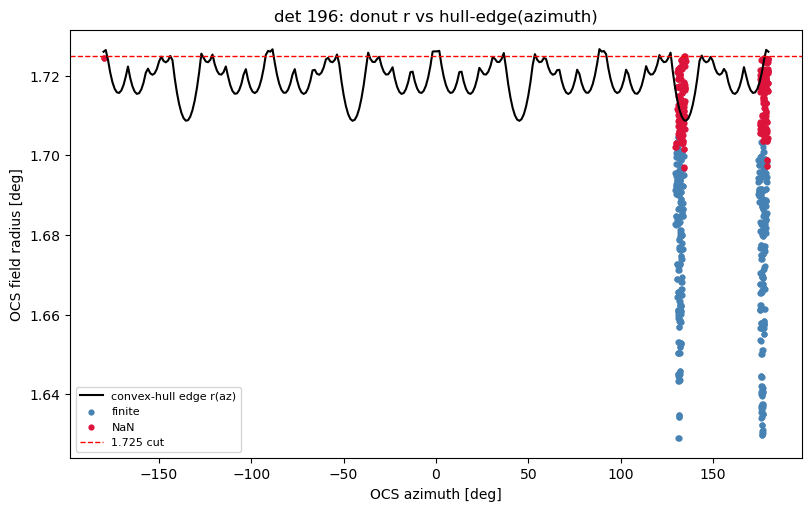

In [13]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.spatial import ConvexHull

DET = 196
cal = calib_by_det[DET]
ox, oy = np.asarray(cal.field_x_ocs, float), np.asarray(cal.field_y_ocs, float)
hull = ConvexHull(np.column_stack([ox, oy]))
A, bvec = hull.equations[:, :2], hull.equations[:, 2]
def edge_r(az):                                  # hull-edge radius along azimuth az
    d = np.array([np.cos(az), np.sin(az)]); den = A @ d
    ts = [-b / v for b, v in zip(bvec, den) if v > 1e-12]
    return min(ts) if ts else np.nan

NOLL_USE = common if "common" in dir() else calib_noll
rec = []
for r in rows:
    rot = RTP_SIGN * r["rtp"]
    for side in ("extra", "intra"):
        m = (np.asarray(r["det_id"]) + (0 if side == "extra" else 1)) == DET
        if not m.any():
            continue
        xO = np.asarray(r[f"thx_OCS_{side}"], float)[m]; yO = np.asarray(r[f"thy_OCS_{side}"], float)[m]
        xC = np.asarray(r[f"thx_CCS_{side}"], float)[m]; yC = np.asarray(r[f"thy_CCS_{side}"], float)[m]
        full = np.isnan(np.atleast_2d(cal.getIntrinsicZernikes(
            field_x=xC, field_y=yC, rotTelPos=float(rot), noll_indices=NOLL_USE))).any(1)
        ocs = np.isnan(np.atleast_2d(cal.interpolator_ocs(np.column_stack([xO, yO])))).any(1)
        for i in range(int(m.sum())):
            rec.append(dict(r=float(np.hypot(xO[i], yO[i])), az=float(np.arctan2(yO[i], xO[i])),
                            full_nan=bool(full[i]), ocs_nan=bool(ocs[i])))
D = pd.DataFrame(rec)
print(f"det {DET}: {len(D)} donuts | full NaN {D.full_nan.mean():.1%} | "
      f"OCS-at-agg-pos NaN {D.ocs_nan.mean():.1%} | agree {(D.full_nan==D.ocs_nan).mean():.1%}")

azs = np.linspace(D.az.min(), D.az.max(), 300)
edge = np.array([edge_r(a) for a in azs])
print(f"hull edge over CCD az span: min {np.nanmin(edge):.4f}  max {np.nanmax(edge):.4f} deg")
print(f"NaN donut radius:           min {D.r[D.full_nan].min():.4f}  "
      f"max {D.r[D.full_nan].max():.4f} deg")

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
ax.plot(np.degrees(azs), edge, "k-", lw=1.5, label="convex-hull edge r(az)")
ax.scatter(np.degrees(D.az[~D.full_nan]), D.r[~D.full_nan], s=12, color="steelblue", label="finite")
ax.scatter(np.degrees(D.az[D.full_nan]),  D.r[D.full_nan],  s=12, color="crimson", label="NaN")
ax.axhline(1.725, color="red", ls="--", lw=1, label="1.725 cut")
ax.set_xlabel("OCS azimuth [deg]"); ax.set_ylabel("OCS field radius [deg]")
ax.set_title(f"det {DET}: donut r vs hull-edge(azimuth)"); ax.legend(fontsize=8)
plt.show()

In [14]:

import numpy as np, matplotlib.pyplot as plt
from scipy.spatial import ConvexHull

cal = calib_by_det[196]
interp = cal.interpolator_ocs
ox, oy = np.asarray(cal.field_x_ocs, float), np.asarray(cal.field_y_ocs, float)
rV = np.hypot(ox, oy)
V = np.asarray(interp.values)                      # values at each vertex
print("n_pts:", len(ox), " interp.points:", np.asarray(interp.points).shape,
      " values:", V.shape, " rescale:", getattr(interp, "rescale", "?"))

anyN = np.isnan(V).any(1)
if anyN.any():
    print(f"** {anyN.sum()} vertices carry NaN values, at r "
          f"{rV[anyN].min():.4f}..{rV[anyN].max():.4f} deg  <-- these poison interior triangles")
    print(f"   all-finite vertices reach r_max = {rV[~anyN].max():.4f} deg")
else:
    print("no vertex has NaN values -> the shrink is purely geometric/rescale")

# actual finite boundary the interpolator produces, per azimuth
azg = np.linspace(-np.pi, np.pi, 361)
rg = np.arange(1.60, 1.76, 0.002)
truebound = np.full(azg.shape, np.nan)
for k, a in enumerate(azg):
    fin = ~np.isnan(np.asarray(interp(np.column_stack([rg*np.cos(a), rg*np.sin(a)])))).any(1)
    if fin.any():
        truebound[k] = rg[fin].max()

hull = ConvexHull(np.column_stack([ox, oy]))
A, b = hull.equations[:, :2], hull.equations[:, 2]
def edge(a):
    d = np.array([np.cos(a), np.sin(a)]); den = A @ d
    ts = [-bi/di for bi, di in zip(b, den) if di > 1e-12]
    return min(ts) if ts else np.nan
geohull = np.array([edge(a) for a in azg])

plt.figure(figsize=(9, 5))
plt.plot(np.degrees(azg), geohull,   "k-",  label="geometric convex hull")
plt.plot(np.degrees(azg), truebound, "m.-", ms=3, label="actual finite boundary of interp")
plt.axhline(1.725, color="red", ls="--", label="1.725 cut")
plt.xlabel("OCS azimuth [deg]"); plt.ylabel("max finite OCS radius [deg]")
plt.legend(); plt.title("det 196: geometric hull vs actual interpolator finite boundary")
plt.show()
print(f"geometric hull r: {np.nanmin(geohull):.4f}..{np.nanmax(geohull):.4f}")
print(f"actual finite  r: {np.nanmin(truebound):.4f}..{np.nanmax(truebound):.4f}")

In [21]:
import numpy as np, matplotlib.pyplot as plt
from scipy.spatial import ConvexHull

DET = 196
cal = calib_by_det[DET]
interp = cal.interpolator_ocs
ox, oy = np.asarray(cal.field_x_ocs, float), np.asarray(cal.field_y_ocs, float)

# --- geometric convex-hull edge vs azimuth ---
azg = np.linspace(-np.pi, np.pi, 361)
hull = ConvexHull(np.column_stack([ox, oy]))
A, b = hull.equations[:, :2], hull.equations[:, 2]
def edge(a):
    d = np.array([np.cos(a), np.sin(a)]); den = A @ d
    ts = [-bi/di for bi, di in zip(b, den) if di > 1e-12]
    return min(ts) if ts else np.nan
geohull = np.array([edge(a) for a in azg])

# --- actual finite boundary the interpolator produces, per azimuth ---
rg = np.arange(1.60, 1.76, 0.002)
truebound = np.full(azg.shape, np.nan)
for k, a in enumerate(azg):
    fin = ~np.isnan(np.asarray(interp(np.column_stack([rg*np.cos(a), rg*np.sin(a)])))).any(1)
    if fin.any():
        truebound[k] = rg[fin].max()

# --- donuts on DET: OCS (az, r) + any-NaN from the full MIW call ---
NOLL_USE = common if "common" in dir() else calib_noll
R, AZ, NAN = [], [], []
for r in rows:
    rot = RTP_SIGN * r["rtp"]
    for side in ("extra", "intra"):
        m = (np.asarray(r["det_id"]) + (0 if side == "extra" else 1)) == DET
        if not m.any():
            continue
        xO = np.asarray(r[f"thx_OCS_{side}"], float)[m]; yO = np.asarray(r[f"thy_OCS_{side}"], float)[m]
        xC = np.asarray(r[f"thx_CCS_{side}"], float)[m]; yC = np.asarray(r[f"thy_CCS_{side}"], float)[m]
        nan = np.isnan(np.atleast_2d(cal.getIntrinsicZernikes(
            field_x=xC, field_y=yC, rotTelPos=float(rot), noll_indices=NOLL_USE))).any(1)
        R += list(np.hypot(xO, yO)); AZ += list(np.degrees(np.arctan2(yO, xO))); NAN += list(nan)
R, AZ, NAN = np.array(R), np.array(AZ), np.array(NAN, bool)

# --- overlay ---
plt.figure(figsize=(9, 5))
plt.plot(np.degrees(azg), geohull,   "k-",  lw=1.2, label="geometric convex hull")
plt.plot(np.degrees(azg), truebound, "m.-", ms=3, lw=1, label="actual finite boundary of interp")
plt.scatter(AZ[~NAN], R[~NAN], s=6, color="k",   zorder=5, label="donut finite")
plt.scatter(AZ[NAN],  R[NAN],  s=6, color="red", zorder=6, label="donut any NaN")
plt.axhline(1.725, color="red", ls="--", lw=1, label="1.725 cut")
plt.xlim(100.,180.)
plt.xlabel("OCS azimuth [deg]"); plt.ylabel("max finite / donut OCS radius [deg]")
plt.title(f"det {DET}: geometric hull vs actual finite boundary, with donuts")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

print(f"det {DET}: {len(R)} donuts, NaN {NAN.mean():.1%}")
print(f"finite donut r_max = {R[~NAN].max():.4f};  NaN donut r_min = {R[NAN].min():.4f} deg")

In [22]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.spatial import ConvexHull

DET = 196
cal = calib_by_det[DET]
interp = cal.interpolator_ocs
ox, oy = np.asarray(cal.field_x_ocs, float), np.asarray(cal.field_y_ocs, float)
NOLL_USE = common if "common" in dir() else calib_noll

azg = np.linspace(-np.pi, np.pi, 361)
hull = ConvexHull(np.column_stack([ox, oy]))
A, b = hull.equations[:, :2], hull.equations[:, 2]
def edge(a):
    d = np.array([np.cos(a), np.sin(a)]); den = A @ d
    ts = [-bi/di for bi, di in zip(b, den) if di > 1e-12]
    return min(ts) if ts else np.nan
geohull = np.array([edge(a) for a in azg])
def rot(x, y, deg):
    t = np.radians(deg); c, s = np.cos(t), np.sin(t); return c*x - s*y, s*x + c*y

recs = []
for r in rows:
    rt = r["rtp"]
    for side in ("extra", "intra"):
        m = (np.asarray(r["det_id"]) + (0 if side == "extra" else 1)) == DET
        if not m.any():
            continue
        xO = np.asarray(r[f"thx_OCS_{side}"], float)[m]; yO = np.asarray(r[f"thy_OCS_{side}"], float)[m]
        xC = np.asarray(r[f"thx_CCS_{side}"], float)[m]; yC = np.asarray(r[f"thy_CCS_{side}"], float)[m]
        full = np.isnan(np.atleast_2d(cal.getIntrinsicZernikes(
            field_x=xC, field_y=yC, rotTelPos=float(RTP_SIGN*rt), noll_indices=NOLL_USE))).any(1)
        ocs = np.isnan(np.atleast_2d(interp(np.column_stack([xO, yO])))).any(1)
        for i in range(int(m.sum())):
            recs.append(dict(xO=xO[i], yO=yO[i], xC=xC[i], yC=yC[i], rt=rt,
                             full=bool(full[i]), ocs=bool(ocs[i])))
D = pd.DataFrame(recs)
D["r"] = np.hypot(D.xO, D.yO); D["az"] = np.degrees(np.arctan2(D.yO, D.xO))

# does the aggregate's CCS->OCS match a rotation by +/- rtp?
for s in (+1, -1):
    px, py = rot(D.xC.values, D.yC.values, s*D.rt.values)
    res = np.hypot(px - D.xO.values, py - D.yO.values)
    print(f"R({s:+d}*rtp)*CCS vs stored OCS: median resid {np.median(res):.4f}, max {res.max():.4f} deg")

print(f"\nfull-call NaN {D.full.mean():.1%} | interp@storedOCS NaN {D.ocs.mean():.1%} | "
      f"agree {(D.full == D.ocs).mean():.1%}")
bad = D.full & ~D.ocs
print(f"NaN in full call but FINITE at stored OCS pos: {bad.sum()} ({bad.mean():.1%})  "
      f"<-- the 'NaN inside the hull' points")

fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True, constrained_layout=True)
for a, (col, lbl) in zip(ax, [("ocs", "colored by interp_ocs at STORED OCS pos"),
                              ("full", "colored by full getIntrinsicZernikes")]):
    a.plot(np.degrees(azg), geohull, "-", color="0.55", lw=1)
    nan = D[col].values
    a.scatter(D.az[~nan], D.r[~nan], s=6, color="k")
    a.scatter(D.az[nan],  D.r[nan],  s=6, color="red")
    a.axhline(1.725, color="red", ls="--", lw=1)
    a.set_xlim(D.az.min()-8, D.az.max()+8); a.set_ylim(1.62, 1.728)
    a.set_xlabel("OCS azimuth [deg]"); a.set_title(lbl, fontsize=9)
ax[0].set_ylabel("OCS radius [deg]")
fig.suptitle(f"det {DET}: NaN by stored-OCS-pos (left) vs full call (right)")
plt.show()

In [23]:
DET = 196; cal = calib_by_det[DET]; interp = cal.interpolator_ocs
k4 = calib_noll.index(4)
NOLL_USE = common if "common" in dir() else calib_noll
o_st, z4, full = [], [], []
for r in rows:
    for side in ("extra", "intra"):
        m = (np.asarray(r["det_id"]) + (0 if side == "extra" else 1)) == DET
        if not m.any():
            continue
        xO = np.asarray(r[f"thx_OCS_{side}"], float)[m]; yO = np.asarray(r[f"thy_OCS_{side}"], float)[m]
        xC = np.asarray(r[f"thx_CCS_{side}"], float)[m]; yC = np.asarray(r[f"thy_CCS_{side}"], float)[m]
        o_st += list(np.isnan(np.atleast_2d(interp(np.column_stack([xO, yO])))).any(1))
        z4   += list(np.isnan(np.atleast_2d(cal.interpolator(np.column_stack([xC, yC])))[:, k4]))
        full += list(np.isnan(np.atleast_2d(cal.getIntrinsicZernikes(
                     field_x=xC, field_y=yC, rotTelPos=float(RTP_SIGN*r["rtp"]),
                     noll_indices=NOLL_USE))).any(1))
import numpy as np
o_st, z4, full = map(np.array, (o_st, z4, full))
print(f"OCS@stored {o_st.mean():.1%} | CCS-Z4 {z4.mean():.1%} | full {full.mean():.1%}")
print(f"(OCS@stored | CCS-Z4) == full : {((o_st | z4) == full).mean():.1%}")
den = (full & ~o_st).sum()
print(f"'NaN inside OCS hull' explained by CCS-Z4: {(full & ~o_st & z4).sum()}/{den}")

In [24]:
import numpy as np, matplotlib.pyplot as plt
from scipy.spatial import ConvexHull

DET = 196
cal = calib_by_det[DET]
fx, fy = np.asarray(cal.field_x, float), np.asarray(cal.field_y, float)
k4 = calib_noll.index(4)

# donuts on this det (CCS positions) + Z4-NaN
X, Y, NAN = [], [], []
for r in rows:
    for side in ("extra", "intra"):
        m = (np.asarray(r["det_id"]) + (0 if side == "extra" else 1)) == DET
        if not m.any():
            continue
        xC = np.asarray(r[f"thx_CCS_{side}"], float)[m]; yC = np.asarray(r[f"thy_CCS_{side}"], float)[m]
        z4 = np.isnan(np.atleast_2d(cal.interpolator(np.column_stack([xC, yC])))[:, k4])
        X += list(xC); Y += list(yC); NAN += list(z4)
X, Y, NAN = np.array(X), np.array(Y), np.array(NAN, bool)

hull = ConvexHull(np.column_stack([fx, fy]))
hv = np.append(hull.vertices, hull.vertices[0])
fig, ax = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

# (A) 2D CCS field space: finite region (shaded), sample hull, donuts
gx = np.linspace(min(fx.min(), X.min()) - 0.02, max(fx.max(), X.max()) + 0.02, 250)
gy = np.linspace(min(fy.min(), Y.min()) - 0.02, max(fy.max(), Y.max()) + 0.02, 250)
GX, GY = np.meshgrid(gx, gy)
fin = ~np.isnan(np.atleast_2d(cal.interpolator(np.column_stack([GX.ravel(), GY.ravel()])))[:, k4])
ax[0].contourf(GX, GY, fin.reshape(GX.shape), levels=[0.5, 1.5], colors=["#d8f0d8"])
ax[0].plot(fx[hv], fy[hv], "g-", lw=1, label="geometric hull of CCS samples")
ax[0].scatter(fx, fy, s=2, color="green", alpha=0.4)
ax[0].scatter(X[~NAN], Y[~NAN], s=8, color="k", label="donut finite")
ax[0].scatter(X[NAN],  Y[NAN],  s=8, color="red", label="donut Z4 NaN")
ax[0].set_aspect("equal"); ax[0].set_xlabel("thx_CCS [deg]"); ax[0].set_ylabel("thy_CCS [deg]")
ax[0].set_title(f"det {DET}: CCS-Z4 footprint (green=finite region)"); ax[0].legend(fontsize=7)

# (B) radius vs CCS azimuth: geometric hull edge + actual finite boundary + donuts
rC, azC = np.hypot(X, Y), np.degrees(np.arctan2(Y, X))
A, b = hull.equations[:, :2], hull.equations[:, 2]
def edge(a):
    d = np.array([np.cos(a), np.sin(a)]); den = A @ d
    ts = [-bi/di for bi, di in zip(b, den) if di > 1e-12]
    return min(ts) if ts else np.nan
azg = np.radians(np.linspace(azC.min() - 3, azC.max() + 3, 240))
geo = np.array([edge(a) for a in azg])
rg = np.arange(rC.min() - 0.03, rC.max() + 0.03, 0.002)
tb = np.full(azg.shape, np.nan)
for k, a in enumerate(azg):
    f = ~np.isnan(np.atleast_2d(cal.interpolator(np.column_stack([rg*np.cos(a), rg*np.sin(a)])))[:, k4])
    if f.any():
        tb[k] = rg[f].max()
ax[1].plot(np.degrees(azg), geo, "g-", lw=1.2, label="geometric hull")
ax[1].plot(np.degrees(azg), tb, "m.-", ms=3, label="actual finite boundary")
ax[1].scatter(azC[~NAN], rC[~NAN], s=8, color="k", label="donut finite")
ax[1].scatter(azC[NAN],  rC[NAN],  s=8, color="red", label="donut Z4 NaN")
ax[1].axhline(1.725, color="red", ls="--", lw=1, label="1.725 cut")
ax[1].set_xlabel("CCS azimuth [deg]"); ax[1].set_ylabel("CCS field radius [deg]")
ax[1].set_title(f"det {DET}: CCS-Z4 hull-edge(azimuth)"); ax[1].legend(fontsize=7)
plt.show()

print(f"det {DET}: CCS-Z4 NaN {NAN.mean():.1%}")
print(f"CCS samples r: {np.hypot(fx, fy).min():.4f}..{np.hypot(fx, fy).max():.4f} deg  (n={len(fx)})")
print(f"donuts r:      {rC.min():.4f}..{rC.max():.4f}  (finite r_max {rC[~NAN].max():.4f}, "
      f"NaN r_min {rC[NAN].min():.4f})")

In [25]:
import numpy as np, pandas as pd
k4 = calib_noll.index(4)
def det_r_nan(DET):
    R, N = [], []
    for r in rows:
        for side in ("extra", "intra"):
            m = (np.asarray(r["det_id"]) + (0 if side == "extra" else 1)) == DET
            if not m.any():
                continue
            xC = np.asarray(r[f"thx_CCS_{side}"], float)[m]; yC = np.asarray(r[f"thy_CCS_{side}"], float)[m]
            z4 = np.isnan(np.atleast_2d(calib_by_det[DET].interpolator(np.column_stack([xC, yC])))[:, k4])
            R += list(np.hypot(xC, yC)); N += list(z4)
    return np.array(R), np.array(N, bool)

out = []
for DET in sorted(calib_by_det):
    cal = calib_by_det[DET]; fxy = np.hypot(np.asarray(cal.field_x, float), np.asarray(cal.field_y, float))
    rr, nn = det_r_nan(DET)
    out.append(dict(det=DET, n_ccs=len(fxy), ccs_rmax=fxy.max(),
                    donut_rmax=(rr.max() if len(rr) else np.nan),
                    z4_nan=(nn.mean() if len(nn) else np.nan)))
print(pd.DataFrame(out).to_string(index=False,
      formatters={"ccs_rmax": "{:.4f}".format, "donut_rmax": "{:.4f}".format, "z4_nan": "{:.1%}".format}))

In [28]:
import glob, os, numpy as np, pandas as pd, matplotlib.pyplot as plt

# EDIT to point at the chunked donut parquet output of the MIW build:
GLOB = "output/fam_danish_1_2_0_wep17_6_1_refitWCS_bin2x/chunks/20260315_20260327/donuts.parquet"
MAXFILES = 40                                  # sample this many chunks

files = sorted(glob.glob(os.path.expanduser(GLOB), recursive=True))
assert files, f"no files matched {GLOB} -- fix the path"
print(f"{len(files)} files matched; using first {min(len(files), MAXFILES)}")

# inspect the schema of the first chunk
c0 = pd.read_parquet(files[0])
print("columns:", list(c0.columns))

# pick a field-position pair (OCS preferred)
cands = [("thx_OCS", "thy_OCS"), ("thx_CCS", "thy_CCS"), ("field_x", "field_y"),
         ("thx", "thy"), ("fieldX", "fieldY"), ("focal_x", "focal_y")]
pair = next((p for p in cands if p[0] in c0.columns and p[1] in c0.columns), None)
assert pair, f"no field-angle columns recognized; columns were {list(c0.columns)}"
fx, fy = pair
print("using field columns:", pair)

d = pd.concat([pd.read_parquet(f, columns=list(pair)) for f in files[:MAXFILES]],
              ignore_index=True)
x, y = np.asarray(d[fx], float), np.asarray(d[fy], float)
r = np.hypot(x, y)
if np.nanmax(np.abs(np.r_[x, y])) < 0.2:       # radians -> degrees
    r = np.degrees(r); unit = "deg (from radians)"
else:
    unit = "deg"

print(f"\n{len(r)} donuts")
for p in (95, 99, 99.5, 99.9, 100):
    print(f"  r {p:5.1f} pct = {np.nanpercentile(r, p):.4f} {unit}")

plt.figure(figsize=(8, 5))
plt.hist(r, bins=150, range=(1.65,1.8),color="0.7")
for v, c, l in [(1.708, "green", "current MIW hull ~1.708"),
                (1.725, "red", "donut_viz cut 1.725"),
                (1.75, "k", "FoV radius 1.75")]:
    plt.axvline(v, color=c, ls="--", lw=1.2, label=l)
plt.xlabel(f"field radius [{unit}]"); plt.ylabel("donuts")
plt.title(f"FAM donut field radius  ({len(files[:MAXFILES])} chunks)")
plt.legend(); plt.tight_layout(); plt.show()